# Retail Sales Forecasting & Inventory Optimization

**Business question:** *Can we forecast future store sales and use those forecasts to make smarter inventory decisions?*

This notebook tells the story end to end. It reuses the project's `src/` modules and loads the
artifacts produced by the pipeline scripts, so it runs in seconds rather than retraining.

> **Portfolio prototype.** Not a production system; the inventory layer uses **simulated** on-hand stock.

**Before running this notebook**, run the pipeline once from the project root:

```bash
python src/data_prep.py
python src/features.py
python src/modeling.py
python src/inventory.py
python src/visualization.py
```


In [1]:
# Setup: resolve the project root whether this runs from notebooks/ or the root,
# then make src/ importable.
import sys, json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd()
if (ROOT / "src").exists():
    pass
elif (ROOT.parent / "src").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))

DATA = ROOT / "data"
OUT = ROOT / "outputs"
print("Project root:", ROOT)

Project root: /Users/sara/Sara_data/github_repos/Retail-Sales-Forecasting-Inventory


## 1. Load the cleaned, merged data

`src/data_prep.py` parses dates, merges `train.csv` with `store.csv`, fills missing store metadata,
and sorts by (Store, Date). Here we just load its output.

In [2]:
clean = pd.read_parquet(DATA / "clean_merged.parquet")
print("rows x cols:", clean.shape)
print("date range :", clean["Date"].min().date(), "->", clean["Date"].max().date())
print("stores     :", clean["Store"].nunique())
clean.head()

rows x cols: (1017209, 18)
date range : 2013-01-01 -> 2015-07-31
stores     : 1115


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,2,2013-01-01,0,0,0,0,a,1,c,a,1270.0,9,2008,0,0,0,None
1,1,3,2013-01-02,5530,668,1,0,0,1,c,a,1270.0,9,2008,0,0,0,None
2,1,4,2013-01-03,4327,578,1,0,0,1,c,a,1270.0,9,2008,0,0,0,None
3,1,5,2013-01-04,4486,619,1,0,0,1,c,a,1270.0,9,2008,0,0,0,None
4,1,6,2013-01-05,4997,635,1,0,0,1,c,a,1270.0,9,2008,0,0,0,None


## 2. Exploratory data analysis

We look only at **open days with positive sales** — closed-day zeros would distort every average.

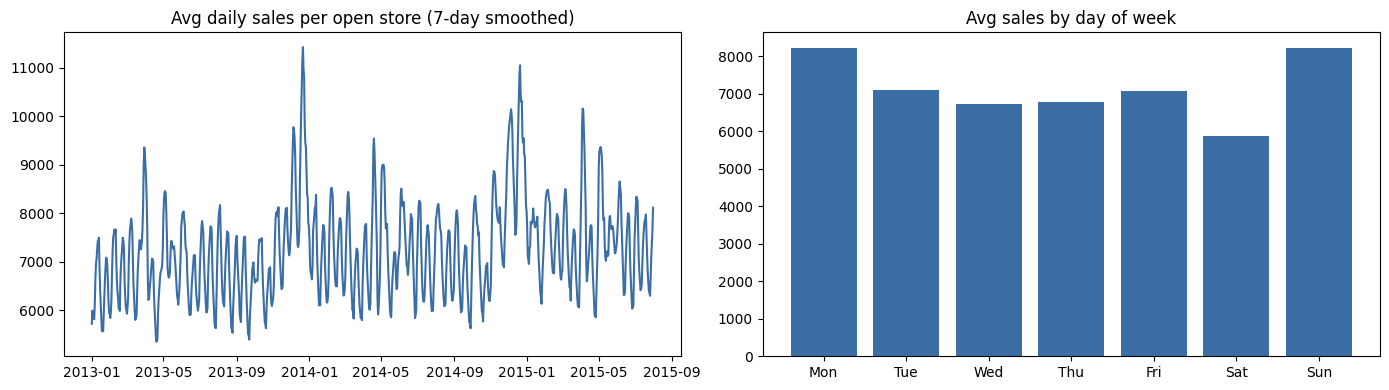

In [3]:
eda = clean[(clean["Open"] == 1) & (clean["Sales"] > 0)]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
daily = eda.groupby("Date")["Sales"].mean()
axes[0].plot(daily.index, daily.rolling(7, min_periods=1).mean(), color="#3b6ea5")
axes[0].set_title("Avg daily sales per open store (7-day smoothed)")

dow = eda.groupby("DayOfWeek")["Sales"].mean().reindex([1,2,3,4,5,6,7])
axes[1].bar(["Mon","Tue","Wed","Thu","Fri","Sat","Sun"], dow.values, color="#3b6ea5")
axes[1].set_title("Avg sales by day of week")
plt.tight_layout(); plt.show()

In [4]:
# Promotions clearly lift sales — a key driver the model should pick up.
promo = eda.groupby("Promo")["Sales"].mean()
print(f"Avg sales  no-promo: {promo.get(0, float('nan')):.0f}")
print(f"Avg sales  promo   : {promo.get(1, float('nan')):.0f}")
lift = (promo.get(1, 0) / promo.get(0, 1) - 1) * 100
print(f"Promotion lift     : {lift:.1f}%")

Avg sales  no-promo: 5930
Avg sales  promo   : 8229
Promotion lift     : 38.8%


## 3. Features and the leakage guard

`src/features.py` adds calendar fields, encoded categoricals, a `Promo2Active` flag, and the
**leakage-safe** lag/rolling features. The key idea: every lag/rolling value is shifted so a row
only ever sees data from *before* its own date. Below we demonstrate that `sales_lag_7` for a row
equals that store's actual sales exactly 7 days earlier.

In [5]:
feat = pd.read_parquet(DATA / "features.parquet")
engineered = ["year","month","week","day","day_of_week","is_weekend",
              "StoreType_enc","Assortment_enc","StateHoliday_enc","Promo2Active",
              "sales_lag_7","sales_lag_14","sales_lag_28",
              "rolling_mean_7","rolling_mean_14","rolling_mean_28","store_expanding_mean"]
print("Engineered features present:", [c for c in engineered if c in feat.columns])

# Leakage check on one store: lag_7 today == Sales 7 rows earlier (same weekday last week).
s = feat[feat["Store"] == feat["Store"].iloc[0]].sort_values("Date").reset_index(drop=True)
i = 40
print(f"\nRow {i}: Sales={s.loc[i,'Sales']:.0f}, sales_lag_7={s.loc[i,'sales_lag_7']:.0f}, "
      f"actual sales 7 rows earlier={s.loc[i-7,'Sales']:.0f}")
assert s.loc[i, "sales_lag_7"] == s.loc[i-7, "Sales"]
print("Leakage guard verified: lag only ever looks backward.")

Engineered features present: ['year', 'month', 'week', 'day', 'day_of_week', 'is_weekend', 'StoreType_enc', 'Assortment_enc', 'StateHoliday_enc', 'Promo2Active', 'sales_lag_7', 'sales_lag_14', 'sales_lag_28', 'rolling_mean_7', 'rolling_mean_14', 'rolling_mean_28', 'store_expanding_mean']

Row 40: Sales=0, sales_lag_7=0, actual sales 7 rows earlier=0
Leakage guard verified: lag only ever looks backward.


## 4. Models and evaluation

`src/modeling.py` uses a **strict time-based split** (final 6 weeks held out), trains a
**baseline** (previous 7-day average) and **XGBoost**, and computes MAE / RMSE / SMAPE / MAPE.
We load the saved metrics rather than retraining.

In [6]:
metrics = json.load(open(OUT / "metrics" / "metrics.json"))
comp = pd.DataFrame({"Baseline (7d avg)": metrics["baseline"], "XGBoost": metrics["xgboost"]})
comp = comp.loc[["MAE","RMSE","SMAPE","MAPE"]].round(2)
improve = (metrics["baseline"]["MAE"] - metrics["xgboost"]["MAE"]) / metrics["baseline"]["MAE"] * 100
print(f"XGBoost improves MAE by {improve:.1f}% over the baseline.\n")
comp

XGBoost improves MAE by 63.7% over the baseline.



,Baseline (7d avg),XGBoost
MAE,1597.34,579.05
RMSE,2323.40,840.64
SMAPE,23.78,8.50
MAPE,22.04,8.74


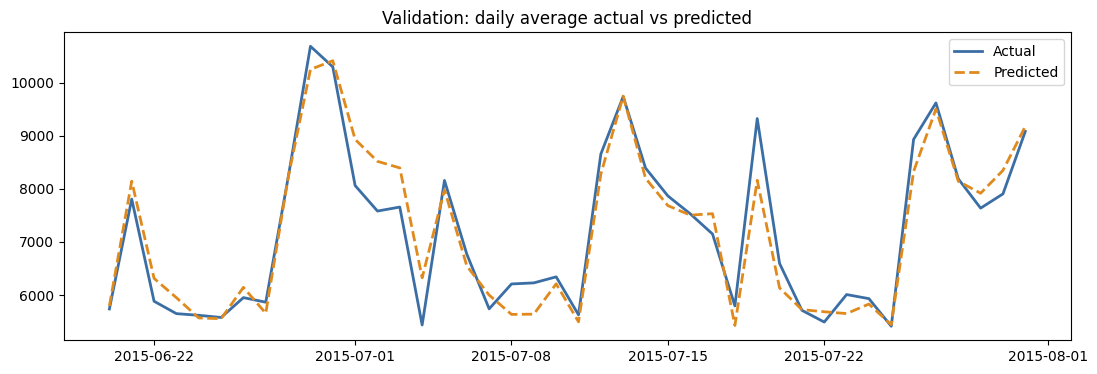

In [7]:
# Daily average actual vs predicted across the validation window.
preds = pd.read_parquet(OUT / "predictions" / "validation_predictions.parquet")
daily = preds.groupby("Date")[["Sales","y_pred_xgb"]].mean()
plt.figure(figsize=(13,4))
plt.plot(daily.index, daily["Sales"], color="#3b6ea5", lw=2, label="Actual")
plt.plot(daily.index, daily["y_pred_xgb"], color="#e08a1e", lw=2, ls="--", label="Predicted")
plt.title("Validation: daily average actual vs predicted"); plt.legend(); plt.show()

### Feature importance

Saved by `modeling.py`. The top features are usually promotion, recent rolling/lag sales, and
day-of-week — an intuitive, defensible story.

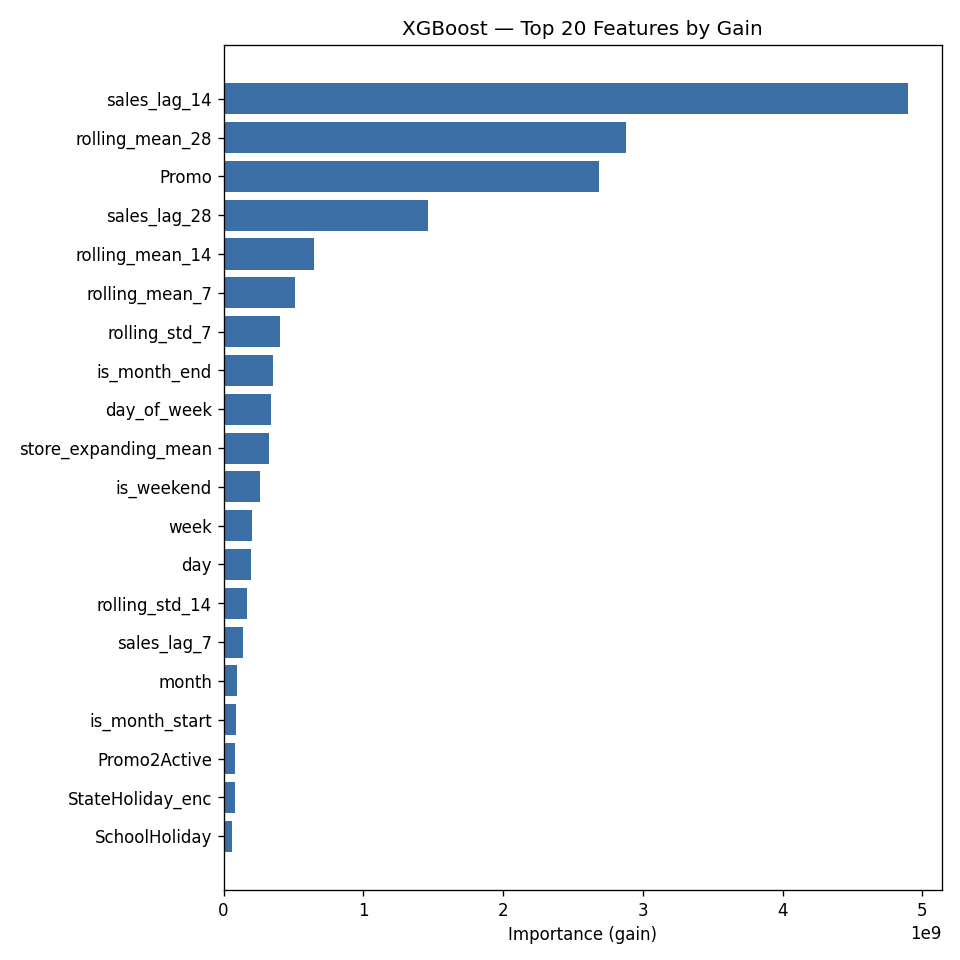

In [8]:
from IPython.display import Image, display
imp = OUT / "figures" / "feature_importance.png"
display(Image(filename=str(imp))) if imp.exists() else print("Run modeling.py to create feature_importance.png")

## 5. From forecasts to inventory decisions

`src/inventory.py` converts each forecast into an order recommendation:

`recommended_order_quantity = predicted_demand + safety_stock - current_inventory`

Safety stock is sized from each store's recent forecast error (`z * recent_error_std`, 95% service
level). Current inventory is **simulated** (clearly prefixed `sim_`). Each row gets a low/medium/high
stockout risk flag.

In [9]:
inv = pd.read_parquet(OUT / "predictions" / "inventory_recommendations.parquet")
display(inv.head(8))

risk = inv["risk_flag"].value_counts(normalize=True).reindex(["low","medium","high"]) * 100
print("\nStockout risk mix (simulated):")
for k, v in risk.items():
    print(f"  {k:<7}: {v:4.1f}%")

,Store,Date,predicted_demand,safety_stock,sim_current_inventory,recommended_order_qty,risk_flag
0,1,2015-06-20,4125.0,562.0,4943.0,0.0,low
1,1,2015-06-22,3936.0,562.0,4123.0,375.0,medium
2,1,2015-06-23,3721.0,562.0,4601.0,0.0,low
3,1,2015-06-24,3443.0,562.0,4007.0,0.0,low
4,1,2015-06-25,3537.0,562.0,3156.0,943.0,high
5,1,2015-06-26,3811.0,562.0,4913.0,0.0,low
6,1,2015-06-27,4029.0,562.0,4804.0,0.0,low
7,1,2015-06-29,5715.0,562.0,6879.0,0.0,low



Stockout risk mix (simulated):
  low    : 26.6%
  medium : 40.1%
  high   : 33.3%


## 6. Business impact, limitations, and takeaways

**Why this matters.** A reliable short-horizon forecast lets a planner order closer to true demand,
hold a sensible buffer where uncertainty is high, and triage the riskiest stores first — less
stockout risk, less over-ordering, less manual guesswork.

**Limitations (stated honestly).**
- On-hand inventory is **simulated**; order quantities show the logic, not real decisions.
- Safety stock is estimated on the validation window — production would use a rolling trailing error.
- Rolling features include closed-day zeros (consistent at train/predict time, so not leakage, but improvable).
- One global model, raw-scale target, default-ish parameters — no per-store models or tuning yet.

**What I learned / would do next.** Tree-based models are a strong, explainable default for tabular
retail forecasting; the biggest wins next would be a `log1p` target + tuning, quantile forecasts to
size safety stock directly, and real inventory/lead-time data to replace the simulated layer.
